In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# 1. Load the dataset
df = pd.read_csv('D:\Personal\project\REGRESSION_ANALYSIS\Data\combined_data.csv')

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\AAYUSHI\AppData\Local\Temp\ipykernel_22700\958363874.py:2: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv('D:\Personal\project\Canada_Food_Regression\Data\combined_data.csv')


In [16]:
#province wise time regression analysis e.g ontario
df_ontario = df[df['Province'] == 'ONTARIO'].copy()

In [17]:
# Convert to datetime and sort by date
df_ontario['Date'] = pd.to_datetime(df_ontario['Date'], format='%d-%m-%Y')
df_ontario = df_ontario.sort_values('Date')

# Create a numerical Time_Index (Months elapsed since Jan 2005)
# This serves as our Feature (X)
df_ontario['Time_Index'] = np.arange(len(df_ontario))

In [18]:
X = df_ontario[['Time_Index']]
y = df_ontario['Composite_HPI_SA']

In [37]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
std_error = np.std(y - y_pred) # Measure of historic price swings
print(f"Monthly Growth Rate (Slope): {model.coef_[0]:.4f}")

Monthly Growth Rate (Slope): 1.0506


In [ ]:
# 2. Forecast Future Trends
# (Indices for 24 months into the future)
last_index = df_ontario['Time_Index'].max()
last_date = df_ontario['Date'].max()

X_future = np.array(range(last_index + 1, last_index + 25)).reshape(-1, 1)
y_future_preds = model.predict(X_future)

# Generate corresponding future dates
future_dates = [last_date + pd.DateOffset(months=i) for i in range(1, 25)]
df_forecast = pd.DataFrame({'Date': future_dates, 'Predicted_HPI': y_future_preds})

c:\Users\AAYUSHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [38]:
# 3. Calculate Confidence Range (95% Probability)
# We use ± 1.96 * standard deviation of residuals
lower_bound = y_future_preds - (1.96 * std_error)
upper_bound = y_future_preds + (1.96 * std_error)


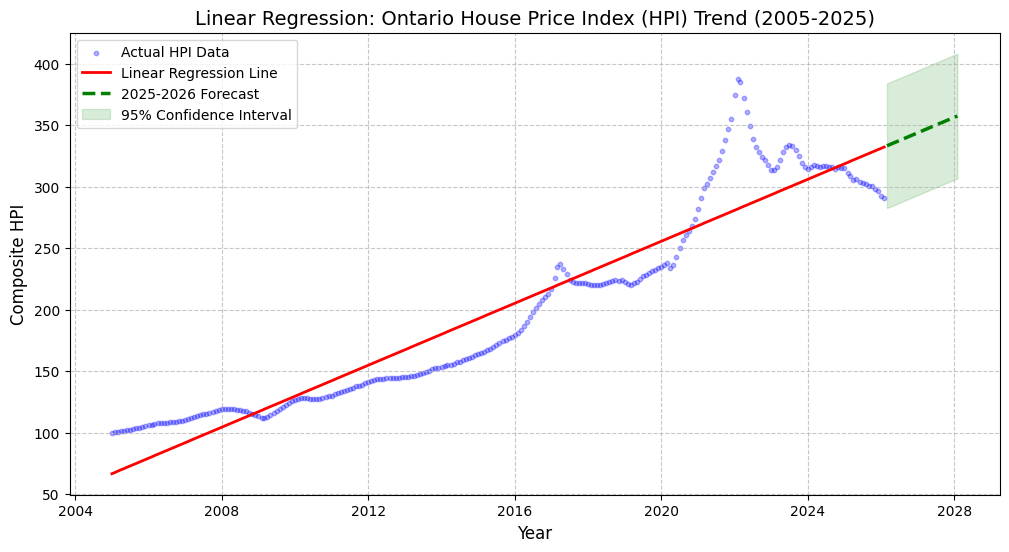

In [ ]:
# 4. Visualizing with Matplotlib
plt.figure(figsize=(12, 6))

# Plot the individual data points (Scatter)
plt.scatter(df_ontario['Date'], y, color='blue', alpha=0.3, label='Actual HPI Data', s=10)

# Plot the regression trend line (Line)
plt.plot(df_ontario['Date'], y_pred, color='red', linewidth=2, label='Linear Regression Line')

# Future Trend Line (Dashed Green)
plt.plot(future_dates, y_future_preds, color='green', linestyle='--', linewidth=2.5, label='2025-2026 Forecast')

# Add the Shaded Confidence Interval
plt.fill_between(future_dates, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

# Chart Aesthetics
plt.title('Linear Regression: Ontario House Price Index (HPI) Trend (2005-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Composite HPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot for your dashboard/portfolio
plt.savefig('D:\\Personal\\project\\REGRESSION_ANALYSIS\\.vscode\\Figures\\ontario_lr_plot.png')